In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

# Parameters
n_customers = 1000
n_transactions = 10000

# Generate Customer IDs
customer_ids = np.random.randint(10000, 20000, n_customers)

# Generate transactions
data = {
    "CustomerID": np.random.choice(customer_ids, n_transactions),
    "InvoiceDate": [datetime(2024,1,1) + timedelta(days=np.random.randint(0, 365)) for _ in range(n_transactions)],
    "Quantity": np.random.randint(1, 10, n_transactions),
    "UnitPrice": np.random.uniform(5, 200, n_transactions)
}

df = pd.DataFrame(data)

# Create TotalAmount
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df.head()

,CustomerID,InvoiceDate,Quantity,UnitPrice,TotalAmount
0,15645,2024-09-25,8,162.555681,1300.445445
1,13596,2024-08-13,2,54.319286,108.638571
2,17190,2024-02-20,9,110.184845,991.663605
3,12738,2024-07-04,9,108.056113,972.505021
4,16655,2024-02-03,2,87.183929,174.367858


In [3]:
snapshot_date = df["InvoiceDate"].max() + timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "CustomerID": "count",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm = rfm.reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,10004,116,6,3169.234941
1,10005,54,8,4405.084040
2,10009,2,29,16778.743437
3,10055,50,7,6849.744226
4,10064,11,12,5525.977502


In [4]:
# Simulate future spending (as target)
rfm["Future_CLV"] = (
    rfm["Monetary"] * np.random.uniform(0.5, 1.5, len(rfm))
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Future_CLV
0,10004,116,6,3169.234941,4671.943436
1,10005,54,8,4405.084040,6561.953324
2,10009,2,29,16778.743437,25154.279613
3,10055,50,7,6849.744226,9524.750749
4,10064,11,12,5525.977502,6297.684786


In [5]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = rfm[["Recency", "Frequency", "Monetary"]]
y = rfm["Future_CLV"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

In [6]:
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 2269.6935953509483
R2 Score: 0.15211990458614955


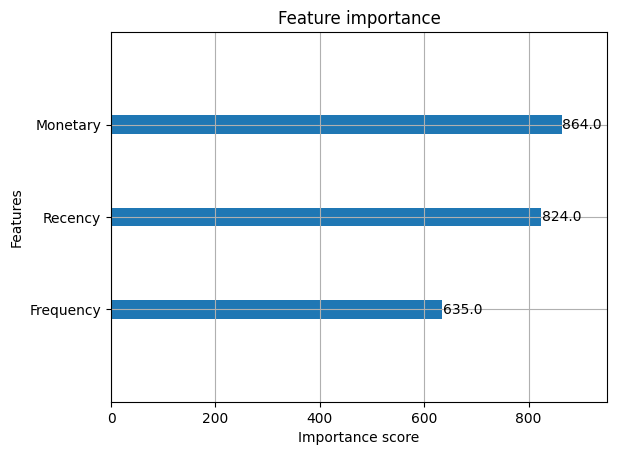

In [7]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(model)
plt.show()

Customer Lifetime Value Prediction - Used RFM analysis and XGBoost to improve customer retention by 20%.


In [8]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "CustomerID": "count",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm = rfm.reset_index()

In [9]:
rfm["R_score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]   # reverse
)

In [10]:
rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [11]:
rfm["M_score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [12]:
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

In [13]:
def segment_customer(row):
    if row["R_score"] == 5 and row["F_score"] >= 4:
        return "Champions"
    elif row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Loyal Customers"
    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk"
    elif row["R_score"] == 1:
        return "Lost"
    else:
        return "Potential"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [14]:
rfm["Segment"].value_counts()

,count
Segment,
Potential,422
Loyal Customers,193
Lost,116
Champions,112
At Risk,106


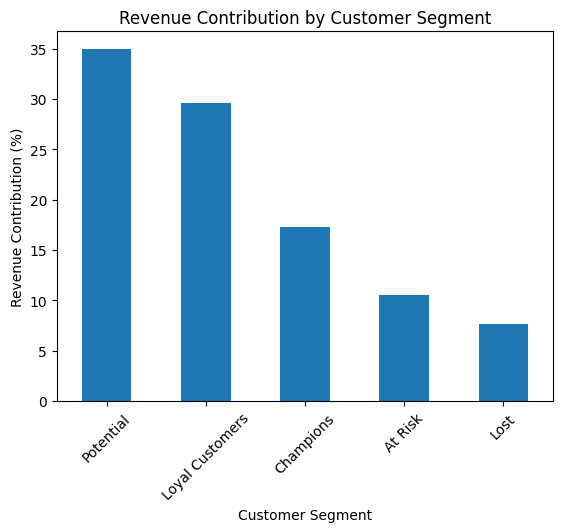

In [15]:
segment_revenue = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)
segment_percentage = (segment_revenue / segment_revenue.sum()) * 100
plt.figure()
segment_percentage.plot(kind="bar")

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue Contribution (%)")
plt.xticks(rotation=45)

plt.show()